In [112]:
import pandas as pd
import numpy as np

In [113]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],inplace=True,axis=1)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [115]:
sex = pd.get_dummies(df.Sex,drop_first=True,dtype=int)
df2 = pd.concat([df,sex],axis=1)

df2['Age'] = df2['Age'].fillna(df2.groupby('Pclass')['Age'].transform('median'))
df2.drop('Sex',axis=1, inplace=True)
df2.head()

,Survived,Pclass,Age,Fare,male
0,0,3,22.0,7.2500,1
1,1,1,38.0,71.2833,0
2,1,3,26.0,7.9250,0
3,1,1,35.0,53.1000,0
4,0,3,35.0,8.0500,1


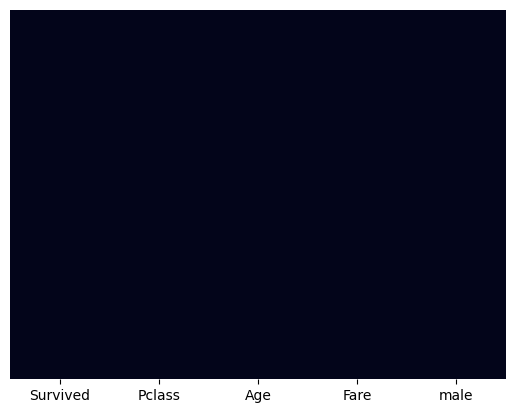

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df2.isnull(), cbar=False, yticklabels=False)
plt.show()

In [117]:
from sklearn.model_selection import train_test_split
X= df2.drop('Survived',axis=1)
y= df2.Survived

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

In [119]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,criterion='gini')

In [120]:
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [121]:
y_pred = dt.predict(X_test)

In [122]:
dt.score(X_test,y_test)

0.7835820895522388